In [115]:
import atproto
from tqdm import autonotebook as tqdm
import networkx as nx
import numpy as np
from matplotlib import pyplot as plt

In [32]:
client = atproto.Client()
profile = client.login('rafael.calsaverini@gmail.com', 'bhregbrekubrecha')
print('Welcome,', profile.displayName)

post_ref = client.send_post(text='Hello World from Python!')
client.like(post_ref)


Welcome, Rafael S. Calsaverini


Response(cid='bafyreibjfszylnlonb44mlxjngexxcpgo7ntyp5k5bxe6mzglghirdrlqu', uri='at://did:plc:ffpltug4j7tkdfcgrvta5tj3/app.bsky.feed.like/3jzmres2a642y')

In [71]:
def get_follows(some_did):
    follows = client.bsky.graph.get_follows(atproto.models.app.bsky.graph.get_follows.models.AppBskyGraphGetFollows.Params(actor=some_did))
    return [
        prof.did
        for prof in follows.follows
    ]

get_follows("did:plc:ffpltug4j7tkdfcgrvta5tj3")

['did:plc:7ba7lz54yll7pxslxv47ejws',
 'did:plc:seem7lvhp7r4n5prbkns27jv',
 'did:plc:phik3h4vonhb64w52kfz5ejs',
 'did:plc:mliymggaxe5zp2s24hqwff3o',
 'did:plc:cz4soyfzoynt7d2p2eodczya',
 'did:plc:2sp7f2rkr6kvnfdasbu25fmr',
 'did:plc:4ohglbfz2vqz7yjjgd3oe6we',
 'did:plc:zs2yk4eq2mnb5slvzctcpb67',
 'did:plc:oqnykvfyzvkw7wunwkmfhdi4',
 'did:plc:wfxbukkez4pfgn6ctr7k6nci',
 'did:plc:qekru2fzohoquhlfkth57z35',
 'did:plc:4rfoqrjdjr7mpceeknxbps4k',
 'did:plc:k4relyfvliy7fpjzdil7ggnp',
 'did:plc:xltfug7ikms4xr3glyuolsdp',
 'did:plc:gpunjjgvlyb4racypz3yfiq4',
 'did:plc:34w2qqfauelc42s57x2mc4dt',
 'did:plc:dc2t4ajxngmuym3om5njlatc',
 'did:plc:ecwk4l4f2dbdjbsx3pywec2s',
 'did:plc:phfnkhx7fve4af55iphyjmf7',
 'did:plc:ckijfrr6ai6vwhdgdbho4sob',
 'did:plc:6ht5cj2lcw3kt7effuil5ppp',
 'did:plc:djj77hmunsbuo6pldzc37vcp',
 'did:plc:lx6j2njrpculwkdx5t7vmhpv',
 'did:plc:w3wnj5nfcqxt26pmx3ajzsrb',
 'did:plc:5vad2bnwjuj5rg7pm5vp54nu',
 'did:plc:lra3edldmyhy4ebxwwcts7bk',
 'did:plc:fqiatejd2mv34wztyh2euto7',
 

In [165]:
queue = [client.me.did]
dones = set()
edges = []
N = 20
bar = tqdm.tqdm(range(N))

while len(dones) < N:
    current_did = queue.pop()
    bar.update()
    for follow_did in get_follows(current_did):
        if follow_did not in dones:
            queue.append(follow_did)
        edges.append((current_did, follow_did))
    dones.add(current_did)

  0%|          | 0/20 [00:00<?, ?it/s]

In [166]:
g = nx.Graph()

In [167]:
g.add_edges_from(edges)

In [168]:
node_set = {n for (n, d) in g.degree if d > 1}
edges = [(l, r) for (l, r) in g.edges if ((l in node_set) and (r in node_set))]
nodes = [n for n in node_set]

In [169]:
pos = nx.layout.spring_layout(
    g,
    k=10,
    fixed=[client.me.did],
    iterations=1000,
    pos = {n: (k * np.random.normal() * 10 , k * np.random.normal() * 10) for (k, n) in enumerate(g.nodes) if n in node_set}
)

In [170]:
xs = np.array([v for v in pos.values()])
x_max, y_max = xs.max(axis=0)
x_min, y_min = xs.min(axis=0)

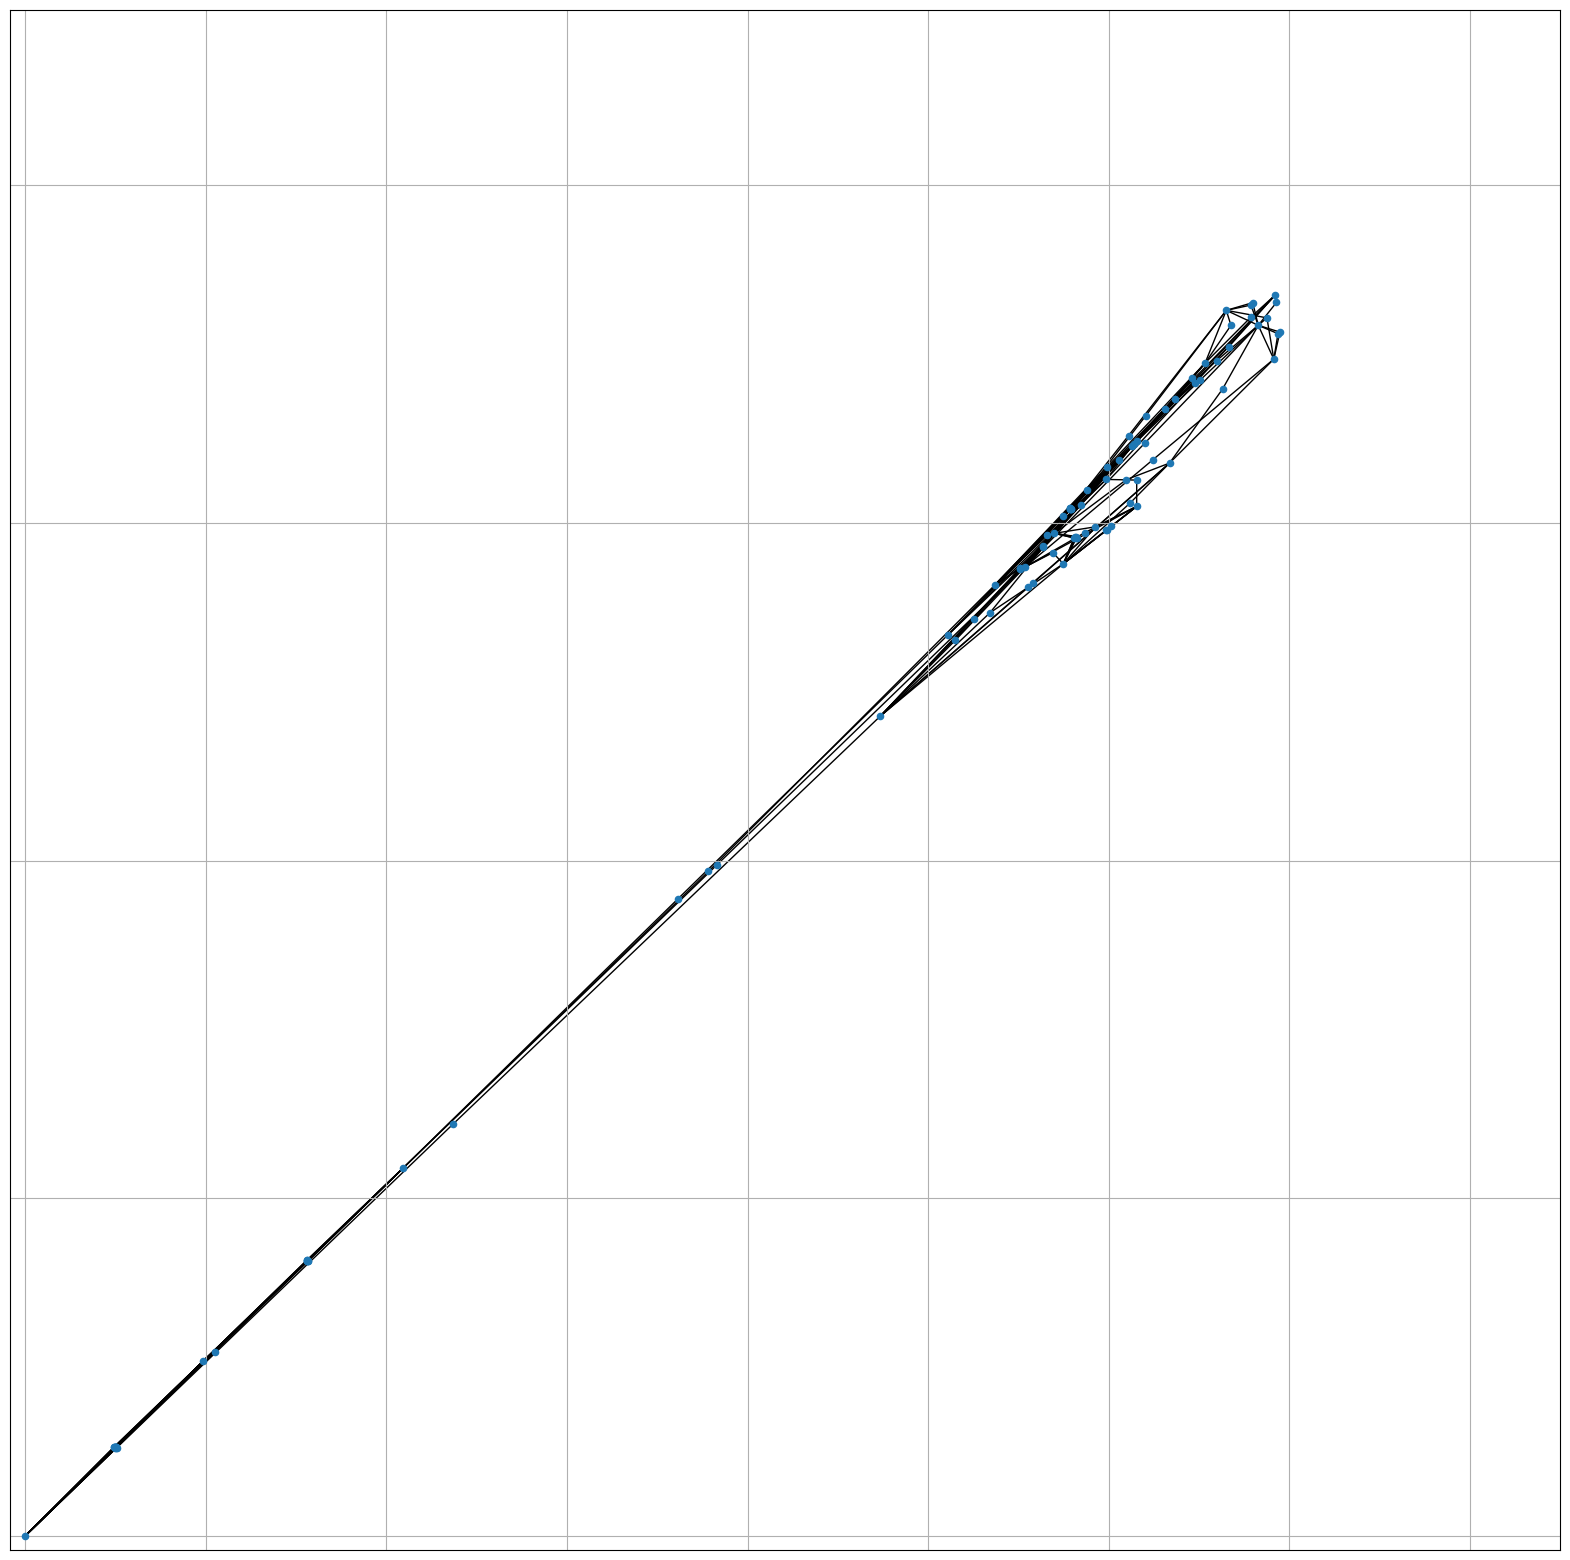

In [171]:
fig, ax = plt.subplots(figsize=(20, 20))
nx.draw_networkx(g, pos=pos, node_size=20, nodelist=nodes, edgelist=edges, ax=ax, with_labels=False)
ax.set_xlim(1.2 * x_min, 1.2 * x_max)
ax.set_ylim(1.2 * y_min, 1.2 * y_max)
ax.grid()